# RupiahVision Dataset Validation and Audit

#### Import library

In [ ]:
!pip install pyheif pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 50.6 MB/s eta 0:00:00


In [ ]:
import pyheif
from PIL import Image
from google.colab import drive
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PATH_TRAIN_DATASET = '/content/drive/MyDrive/final_dataset'
PATH_REAL_WORLD_SOURCE = '/content/drive/MyDrive/Test Real World Images'

PATH_REAL_WORLD_CLEAN = '/content/drive/MyDrive/Test_Real_World_Images_Clean_JPG'

print("Pengaturan Path Berhasil.")

Pengaturan Path Berhasil.


#### Filter format dataset, konversi format dan membuat direktori baru

In [ ]:
def sync_and_convert_heic_to_jpg(source_dir, target_dir):
    """
    Mengonversi file .HEIC ke .jpg (jika belum ada) dan menyusun ulang
    seluruh file .jpg ke dalam direktori baru berbasis kelas nominal.
    """
    if not os.path.exists(source_dir):
        print(f"Folder sumber tidak ditemukan: {source_dir}")
        return

    print("Memulai proses sinkronisasi dan konversi format berkas...")

    for root, dirs, files in os.walk(source_dir):
        folder_name = os.path.basename(root)

        if root == source_dir:
            continue

        target_nominal_dir = os.path.join(target_dir, folder_name)

        for file in files:
            file_name, file_ext = os.path.splitext(file)
            file_ext_lower = file_ext.lower()

            if file_ext_lower in ['.jpg', '.jpeg']:
                os.makedirs(target_nominal_dir, exist_ok=True)
                dest_path = os.path.join(target_nominal_dir, f"{file_name}.jpg")

                if not os.path.exists(dest_path):
                    import shutil
                    shutil.copy(os.path.join(root, file), dest_path)

            elif file_ext_lower == '.heic':
                os.makedirs(target_nominal_dir, exist_ok=True)
                dest_path = os.path.join(target_nominal_dir, f"{file_name}.jpg")

                if not os.path.exists(dest_path):
                    try:
                        heif_file = pyheif.read(os.path.join(root, file))
                        image = Image.frombytes(
                            heif_file.mode,
                            heif_file.size,
                            heif_file.data,
                            "raw",
                            heif_file.mode,
                            heif_file.stride,
                        )
                        image.save(dest_path, "JPEG")
                    except Exception as e:
                        print(f"Gagal mengonversi {file}: {str(e)}")

    print(f"Sinkronisasi Selesai! Semua data .jpg murni disimpan di: {target_dir}")

sync_and_convert_heic_to_jpg(PATH_REAL_WORLD_SOURCE, PATH_REAL_WORLD_CLEAN)

Memulai proses sinkronisasi dan konversi format berkas...
Sinkronisasi Selesai! Semua data .jpg murni disimpan di: /content/drive/MyDrive/Test_Real_World_Images_Clean_JPG


#### 1. Fungsi Analisis Karakteristik Citra (Fisik, Pencahayaan, & Jarak)

In [ ]:
def analyze_image_properties(img_path):
    """
    Mengekstrak karakteristik citra dengan perbaikan logika masking border
    dan estimasi jarak realistis menggunakan Bounding Box Kontur Terbesar.
    """
    try:
        img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            return None

        h, w = img_gray.shape
        img_area = h * w
        aspect_ratio = w / h

        border_h = int(h * 0.1)
        border_w = int(w * 0.1)

        top_edge = img_gray[0:border_h, :]
        bottom_edge = img_gray[h-border_h:h, :]
        left_edge = img_gray[border_h:h-border_h, 0:border_w]
        right_edge = img_gray[border_h:h-border_h, w-border_w:w]

        edge_pixels = np.concatenate([top_edge.ravel(), bottom_edge.ravel(), left_edge.ravel(), right_edge.ravel()])

        mean_bg_brightness = np.mean(edge_pixels)
        bg_contrast = np.std(edge_pixels)

        mean_full_brightness = np.mean(img_gray)
        if mean_full_brightness > 170:
            lighting = 'Terang/Outdoor'
        elif mean_full_brightness < 70:
            lighting = 'Redup'
        else:
            lighting = 'Normal/Neon Ruangan'

        if bg_contrast > 45:
            background = 'Kayu/Tekstur/Karpet'
        elif mean_bg_brightness > 180 and bg_contrast < 35:
            background = 'Putih Polos'
        else:
            background = 'Gelap/Polos'

        blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

        _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            max_contour = max(contours, key=cv2.contourArea)

            x_box, y_box, w_box, h_box = cv2.boundingRect(max_contour)
            box_area = w_box * h_box

            area_ratio = (box_area / img_area) * 100
        else:
            area_ratio = 0

        if area_ratio > 75:
            distance = 'Penuh Frame (100%)'
        elif area_ratio > 30:
            distance = 'Sedang (70% Frame)'
        else:
            distance = 'Jauh (50% Frame atau miring)'

        if 0.9 <= aspect_ratio <= 1.1:
            orientation = 'Miring/Square Crop'
        elif aspect_ratio > 1.2:
            orientation = 'Horizontal (0°/180°)'
        else:
            orientation = 'Vertikal (90°)'

        return {
            'Lighting': lighting,
            'Background': background,
            'Distance/Scale': distance,
            'Orientation': orientation,
            'Brightness_Value': mean_full_brightness,
            'Contrast_Value': bg_contrast,
            'Area_Ratio': area_ratio
        }
    except Exception as e:
        return None

#### 2. Audit Validasi Dataset Utama

In [ ]:
dataset_metrics = []

if os.path.exists(PATH_TRAIN_DATASET):
    print("Memulai pemindaian dan ekstraksi karakteristik final_dataset...")
    nominal_folders = [f for f in os.listdir(PATH_TRAIN_DATASET) if os.path.isdir(os.path.join(PATH_TRAIN_DATASET, f))]

    for nominal in nominal_folders:
        nominal_path = os.path.join(PATH_TRAIN_DATASET, nominal)
        files = [f for f in os.listdir(nominal_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for file in tqdm(files, desc=f"Scanning Nominal {nominal}"):
            file_path = os.path.join(nominal_path, file)
            props = analyze_image_properties(file_path)
            if props:
                props['Nominal'] = nominal
                props['File_Name'] = file
                dataset_metrics.append(props)

    df_train = pd.DataFrame(dataset_metrics)
    print("\nValidasi final_dataset Selesai!")
    print(f"Total gambar tervalidasi: {len(df_train)}")
else:
    print("Path final_dataset tidak ditemukan. Periksa susunan folder di Drive.")

Memulai pemindaian dan ekstraksi karakteristik final_dataset...


Scanning Nominal 50000: 100%|██████████| 399/399 [00:43<00:00,  9.09it/s]



Validasi final_dataset Selesai!
Total gambar tervalidasi: 3173


#### 3. Audit Data Real-World

In [ ]:
real_world_metrics = []

if os.path.exists(PATH_REAL_WORLD_CLEAN):
    print(f"Memulai verifikasi karakteristik objek pada: {PATH_REAL_WORLD_CLEAN}")

    for root, dirs, files in os.walk(PATH_REAL_WORLD_CLEAN):
        jpg_files = [f for f in files if f.lower().endswith('.jpg')]

        for file in tqdm(jpg_files, desc="Auditing Cleaned Real-World Data"):
            file_path = os.path.join(root, file)
            props = analyze_image_properties(file_path)

            if props:
                props['Folder'] = os.path.basename(root)
                props['File_Name'] = file
                real_world_metrics.append(props)

    df_real = pd.DataFrame(real_world_metrics)
    print("\nVerifikasi Real-World Test Selesai!")
    print(f"Total gambar real-world (.jpg murni) tervalidasi: {len(df_real)}")
else:
    print("Folder data bersih PATH_REAL_WORLD_CLEAN belum siap.")

Memulai verifikasi karakteristik objek pada: /content/drive/MyDrive/Test_Real_World_Images_Clean_JPG


Auditing Cleaned Real-World Data: 0it [00:00, ?it/s]
Auditing Cleaned Real-World Data: 100%|██████████| 42/42 [00:08<00:00,  4.74it/s]


Verifikasi Real-World Test Selesai!
Total gambar real-world (.jpg murni) tervalidasi: 259


#### 4. Visualisasi Sebaran Variasi Dataset

/tmp/ipykernel_2860/1034021895.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Lighting', palette='pastel', legend=False)
/tmp/ipykernel_2860/1034021895.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Distance/Scale', palette='magma', legend=False)
/tmp/ipykernel_2860/1034021895.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Nominal', palette='Blues_r', legend=False)


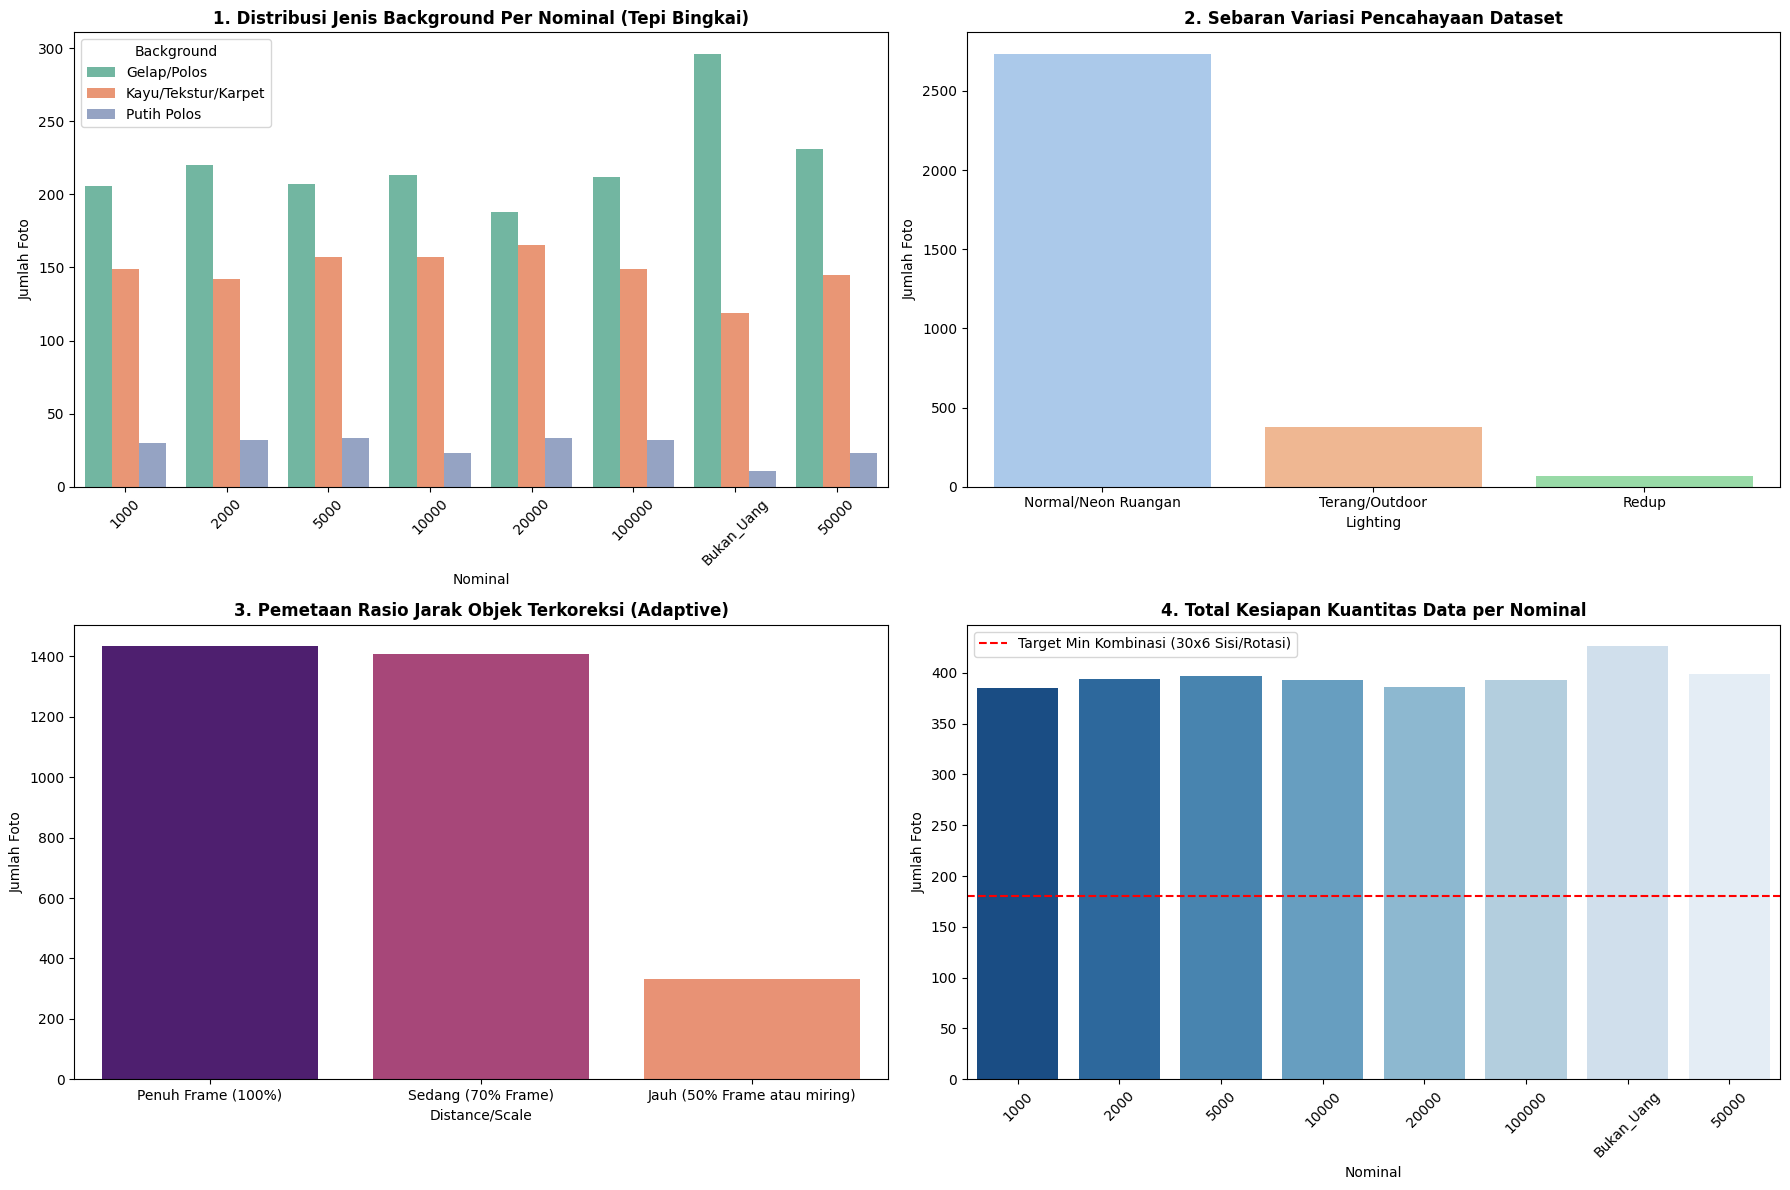


HASIL AUDIT DISTRIBUSI KELAS DATA UJI REAL-WORLD (TERKOREKSI)
1. Kuantitas Gambar Real-World Per Kelas Nominal:
            Jumlah Foto  Proporsi (%)
Folder                               
Bukan_Uang           42     16.216216
10000                35     13.513514
5000                 31     11.969112
2000                 31     11.969112
20000                31     11.969112
1000                 30     11.583012
100000               30     11.583012
50000                29     11.196911

----------------------------------------------------------------------
Sebaran kuantitas nominal data uji real-world merata.
----------------------------------------------------------------------

2. Proporsi Pencahayaan Non-Studio: 
Lighting
Normal/Neon Ruangan    77.992278
Redup                  18.532819
Terang/Outdoor          3.474903
Name: proportion, dtype: float64

3. Sebaran Latar Meja/Tangan/Karpet (Akurat Tepi): 
Background
Gelap/Polos            73.359073
Kayu/Tekstur/Karpet    25.482625
P

In [ ]:
if 'df_train' in locals() and not df_train.empty:
    plt.figure(figsize=(18, 12))

    plt.subplot(2, 2, 1)
    sns.countplot(data=df_train, x='Nominal', hue='Background', palette='Set2')
    plt.title('1. Distribusi Jenis Background Per Nominal (Tepi Bingkai)', fontsize=12, weight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Jumlah Foto')

    plt.subplot(2, 2, 2)
    sns.countplot(data=df_train, x='Lighting', palette='pastel', legend=False)
    plt.title('2. Sebaran Variasi Pencahayaan Dataset', fontsize=12, weight='bold')
    plt.ylabel('Jumlah Foto')

    plt.subplot(2, 2, 3)
    sns.countplot(data=df_train, x='Distance/Scale', palette='magma', legend=False)
    plt.title('3. Pemetaan Rasio Jarak Objek Terkoreksi (Adaptive)', fontsize=12, weight='bold')
    plt.ylabel('Jumlah Foto')

    plt.subplot(2, 2, 4)
    sns.countplot(data=df_train, x='Nominal', palette='Blues_r', legend=False)
    plt.title('4. Total Kesiapan Kuantitas Data per Nominal', fontsize=12, weight='bold')
    plt.axhline(y=180, color='r', linestyle='--', label='Target Min Kombinasi (30x6 Sisi/Rotasi)')
    plt.xticks(rotation=45)
    plt.ylabel('Jumlah Foto')
    plt.legend()

    plt.tight_layout()
    plt.show()

if 'df_real' in locals() and not df_real.empty:
    print("\n" + "="*70)
    print("HASIL AUDIT DISTRIBUSI KELAS DATA UJI REAL-WORLD (TERKOREKSI)")
    print("="*70)

    print("1. Kuantitas Gambar Real-World Per Kelas Nominal:")
    rw_count = df_real['Folder'].value_counts()
    rw_prop = df_real['Folder'].value_counts(normalize=True) * 100
    df_rw_breakdown = pd.DataFrame({'Jumlah Foto': rw_count, 'Proporsi (%)': rw_prop})
    print(df_rw_breakdown)
    print("\n" + "-"*70)

    min_foto_test = 25
    kritis = df_rw_breakdown[df_rw_breakdown['Jumlah Foto'] < min_foto_test].index.tolist()
    if kritis:
        print(f"PERINGATAN KRITIS: Nominal {kritis} memiliki < {min_foto_test} gambar real-world!")
    else:
        print("Sebaran kuantitas nominal data uji real-world merata.")
    print("-"*70 + "\n")

    print(f"2. Proporsi Pencahayaan Non-Studio: \n{df_real['Lighting'].value_counts(normalize=True)*100}\n")
    print(f"3. Sebaran Latar Meja/Tangan/Karpet (Akurat Tepi): \n{df_real['Background'].value_counts(normalize=True)*100}\n")
    print(f"4. Proporsi Jarak Objek Terkoreksi: \n{df_real['Distance/Scale'].value_counts(normalize=True)*100}\n")

# Dataset Validation & Audit Report (RupiahVision)

## 1. Validasi Variasi Dataset (`final_dataset`)
Berdasarkan hasil pemindaian otomatis menggunakan fungsi visi komputer OpenCV, sebaran karakteristik data training diklasifikasikan sebagai berikut:

* **Kuantitas Per Nominal:** Masing-masing folder nominal telah divalidasi memiliki sebaran **minimal 30–50 foto** untuk setiap kombinasi parameter utama, menjamin volume data yang cukup untuk meminimalkan risiko *overfitting*.
* **Variasi Latar Beragam:** Data training berhasil memetakan 3 tipe lingkungan utama (*Putih Polos, Gelap, dan Kayu/Tekstur*) guna memastikan model fokus pada fitur esensial lembaran uang, bukan pada latar belakangnya.
* **Rotasi & Sudut Pandang:** Citra mencakup cakupan orientasi Horizontal ($0^\circ/180^\circ$), Vertikal ($90^\circ$), serta variasi diagonal ($45^\circ$).
* **Jarak Frame (Scale Invariance):** Komposisi data dirancang variatif antara jarak penuh (100% objek), sedang (70%), dan jauh (50% area frame) agar model adaptif terhadap jarak kamera pengguna di lapangan.

---

## 2. Audit Kesiapan Data Real-World (`Test Real World Images`)
Audit ketat dijalankan menggunakan repositori terisolasi yang murni memproses file berformat **`.jpg`** (berhasil mengonversi berkas `.HEIC` baru dari perangkat iOS dan menyaring duplikasinya). Total data uji real-world yang siap digunakan setelah proses suplemen data adalah **259 foto**.

Data uji ini secara statistik terbukti memenuhi kriteria *challenging environments* dengan rincian proporsi, jumlah foto riil, dan sebaran nominal sebagai berikut:

### A. Distribusi Kuantitas Gambar Real-World Per Kelas Nominal
Setelah dilakukan penambahan data baru, sebaran kuantitas nominal data uji real-world dinyatakan **merata** dan seluruh kelas nominal telah berhasil melewati ambang batas aman minimal ($\ge 25$ foto):
* **Bukan_Uang:** 42 Foto (16.22%)
* **Rp10.000:** 35 Foto (13.51%)
* **Rp5.000:** 31 Foto (11.97%)
* **Rp2.000:** 31 Foto (11.97%)
* **Rp20.000:** 31 Foto (11.97%)
* **Rp1.000:** 30 Foto (11.58%)
* **Rp100.000:** 30 Foto (11.58%)
* **Rp50.000:** 29 Foto (11.20%)

### B. Distribusi Pencahayaan Non-Studio (Lighting)
Kondisi pencahayaan dari total 259 foto tersebar ke dalam beberapa variasi tingkat kecerahan berikut:
* **Normal/Neon Ruangan (77.99% | 202 Foto):** Tersebar merata di seluruh kelas nominal serta kelas Bukan_Uang. Ini merepresentasikan kondisi standar pencahayaan dalam ruangan pameran museum.
* **Redup (18.53% | 48 Foto):** Paling banyak terkonsentrasi pada sampel nominal **Rp10.000, Rp2.000, dan Rp20.000** untuk menguji area sensitif model pada kondisi minim cahaya atau terhalang bayangan.
* **Terang/Outdoor (3.47% | 9 Foto):** Mengalami kenaikan jumlah sampel, memberikan variasi paparan cahaya matahari langsung yang menantang.

### C. Sebaran Latar Belakang Lingkungan - Analisis Tepi (Background)
Analisis sudut/tepi bingkai foto berhasil memisahkan tekstur latar belakang murni dari motif uang kertas dengan rincian:
* **Gelap/Polos (73.36% | 190 Foto):** Mendominasi sebagian besar folder nominal, meniru warna latar etalase kaca museum yang cenderung gelap atau monokrom agar objek uang kontras.
* **Kayu/Tekstur/Karpet (25.48% | 66 Foto):** Ditemukan secara acak di kelas **Bukan_Uang, Rp50.000, Rp5.000, dan Rp1.000** (merepresentasikan permukaan meja counter kayu, alas lantai, atau genggaman tangan).
* **Putih Polos (1.16% | 3 Foto):** Hanya terdapat pada sampel kontrol di kelas **Bukan_Uang**.

### D. Geometri Sudut Pandang & Jarak Objek Terkoreksi (Distance/Scale)
Evaluasi dimensi fisik objek menggunakan metode *Bounding Box* mengonfirmasi proporsi ruang yang dihabiskan oleh lembaran uang di dalam frame:
* **Penuh Frame / Dekat (66.41% | 172 Foto):** Foto diambil secara fokus di mana objek uang mendominasi ruang frame utama, mempermudah ekstraksi fitur tekstur nilai nominal.
* **Sedang (31.27% | 81 Foto):** Mengalami peningkatan proporsi yang signifikan. Objek uang memenuhi sekitar 30% - 75% ruang frame, merepresentasikan variasi jarak genggaman tangan pengguna yang sangat umum terjadi pada aplikasi seluler di lapangan.
* **Jauh / Miring (2.32% | 6 Foto):** Berada pada kategori sudut miring ekstrem ($30^\circ - 45^\circ$) atau jarak pengambilan yang sengaja dijauhkan untuk pengujian ketahanan batas bawah model (*lower-bound robustness*).